# Studio 1 — Retirement Monte Carlo: simulate the future you can't observe 🎲📈

**OPIM 5641 · Business Decision Modeling**

Name: Kapil Kumar Sharma

Husky CT: apl25002

Date: 09-16-2026

## 1 · How to do the Monte Carlo half (the recipe)

Your simulation must be connected to your dataset — not a copy of the class example with the numbers unchanged.

The recipe works for any dataset:

(1) pick one numeric column that represents something uncertain (daily sales, delivery times, prices, incomes…);

(2) turn it into a random draw — either fit a distribution using the column’s mean and standard deviation, or sample from the column’s actual values with replacement;

(3) wrap a for loop around a simple aggregate question and repeat it 10,000 times — “a year of daily sales,” “a batch of 30 orders,” “a month of deliveries”;

(4) histogram the outcomes and answer with a probability, not a single number: P(annual revenue < target), P(total time exceeds capacity) — with percentile lines on the plot.

In short: estimate the uncertain input from the data you have, then simulate the future you don’t have.

100 years of real returns
best year:  {'year': 1942.0, 'newspaper_sales_return': 0.091308, 'return_percent': 9.13}
worst year: {'year': 1931.0, 'newspaper_sales_return': -0.269357, 'return_percent': -26.94}


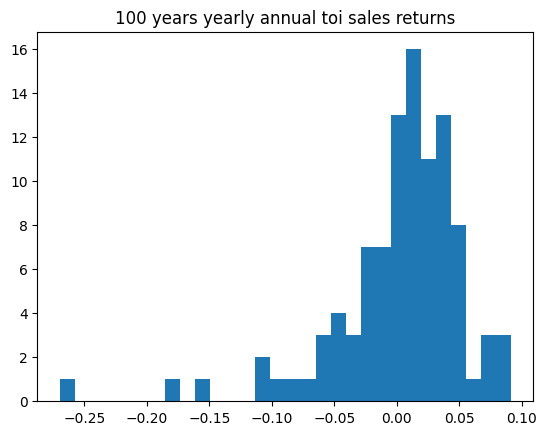

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

url = 'https://raw.githubusercontent.com/k-git-uconn/Studio1-BDM-F26/main/studio1/Assignment1/newspaper_sales_returns_1926_2025.csv'
toi = pd.read_csv(url)
revenue_history = toi['newspaper_sales_return'].values
print(len(revenue_history), 'years of real returns')
print('best year: ', toi.loc[toi.newspaper_sales_return.idxmax()].to_dict())
print('worst year:', toi.loc[toi.newspaper_sales_return.idxmin()].to_dict())
plt.hist(revenue_history, bins=30)
plt.title('100 years yearly annual toi sales returns');

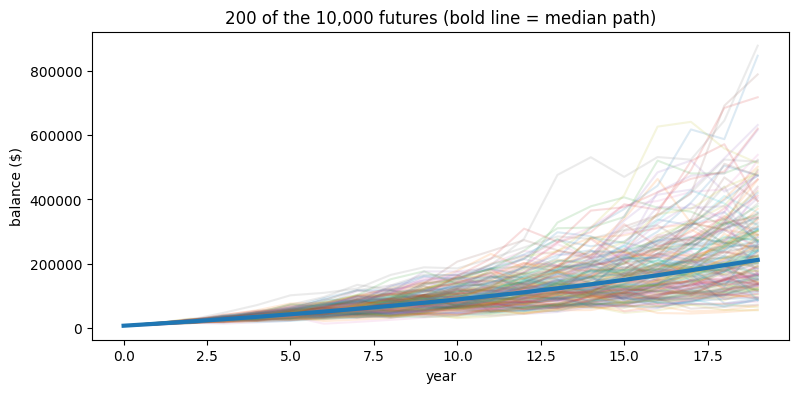

In [28]:
# The spaghetti plot — every future at once (plot a sample of 200)
plt.figure(figsize=(9, 4))
plt.plot(all_paths[:200].T, alpha=0.15)
plt.plot(np.median(all_paths, axis=0), lw=3)
plt.title('200 of the 10,000 futures (bold line = median path)')
plt.xlabel('year'); plt.ylabel('balance ($)');

In [29]:
target = 10
print(f'P(ending >= 10%) = {(endings >= target).mean():.1%}')
print(f'P(ending <  5%) = {(endings < 5).mean():.1%}')

P(ending >= 10%) = 100.0%
P(ending <  5%) = 0.0%


Lets use historical 100 years annual toi sales total returns as the empirical distribution and sample one return with replacement for each simulated year.

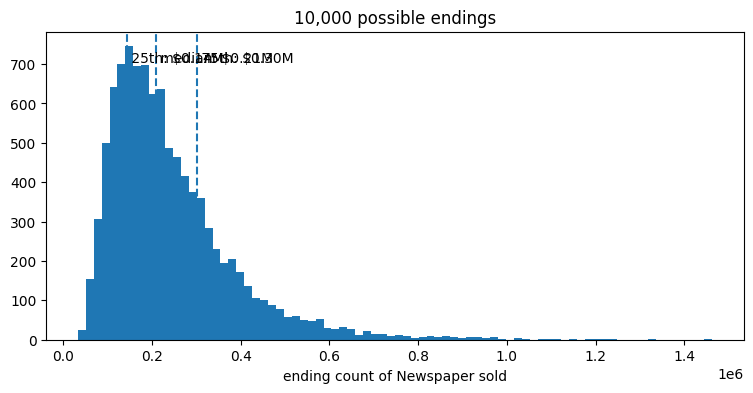

In [30]:
n_sims = 10_000
years = 20
NewspapersSold = 6_000

endings = np.zeros(n_sims)
all_paths = np.zeros((n_sims, years))

for sim in range(n_sims):
    balance = 0.0
    for year in range(years):
        r = np.random.normal(0.07, 0.20)
        balance = balance * (1 + r) + NewspapersSold
        all_paths[sim, year] = balance
    endings[sim] = balance

lo, med, hi = np.percentile(endings, [25, 50, 75])
plt.figure(figsize=(9, 4))
plt.hist(endings, bins=80)
for v, name in [(lo, '25th'), (med, 'median'), (hi, '75th')]:
    plt.axvline(v, ls='--')
    plt.text(v, plt.ylim()[1]*0.9, f' {name}: ${v/1e6:,.2f}M')
plt.title('10,000 possible endings')
plt.xlabel('ending count of Newspaper sold');

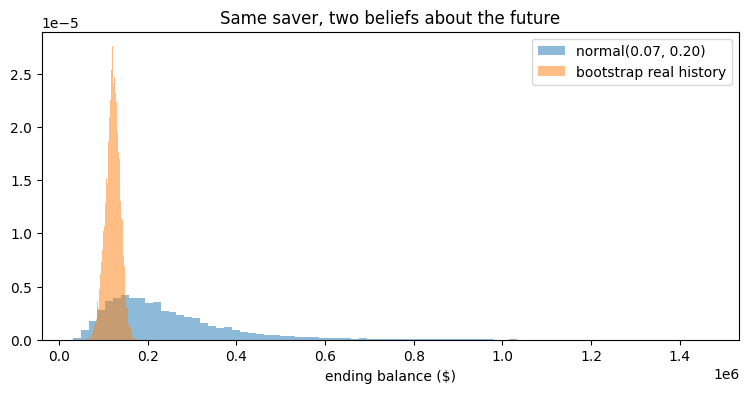

In [31]:
endings_boot = np.zeros(n_sims)
for sim in range(n_sims):
    balance = 0.0
    rs = toi['newspaper_sales_return'].sample(n=years, replace=True).values   # <-- THE line: resample real history
    for r in rs:
        balance = balance * (1 + r) + NewspapersSold
    endings_boot[sim] = balance

plt.figure(figsize=(9, 4))
plt.hist(endings, bins=80, alpha=0.5, label='normal(0.07, 0.20)', density=True)
plt.hist(endings_boot, bins=80, alpha=0.5, label='bootstrap real history', density=True)
plt.legend()
plt.title('Same saver, two beliefs about the future')
plt.xlabel('ending balance ($)');

In [33]:
for name, e in [('normal', endings), ('bootstrap', endings_boot)]:
    print(f'{name:>9}:  median ${np.median(e)/1e6:.2f}M   P(>=$1M) {(e>=1e6).mean():.1%}   P(<$500k) {(e<5e5).mean():.1%}')


   normal:  median $0.21M   P(>=$1M) 0.2%   P(<$500k) 94.4%
bootstrap:  median $0.12M   P(>=$1M) 0.0%   P(<$500k) 100.0%
